In [1]:

import numpy as np

import matplotlib.pyplot as plt

import sys
import os 

import time

module_dir = os.path.abspath(r'C:\Users\Experiment\Documents\Python\VQ_Instruments\my_modules')

sys.path.insert(0, module_dir)

# AWG Initialisation

In [2]:
#Jupyter cell 1 — imports and connection

from rigol_dg922_pro import RigolDG922

RESOURCE = "USB0::0x1AB1::0x0646::DG9R280300043::INSTR"  # update if your VISA address differs
gen = RigolDG922(RESOURCE)  # auto_open=True by default
print("Connected to:", gen.idn)

Connected to: RIGOL TECHNOLOGIES,DG922 Pro,DG9R280300043,00.02.01.00.02


## Set Wavefrom

In [3]:
# Sine wave on CH1, 2 Vpp, 0 V offset
freq=int(1e6)

Vpi=1
coeff=1
Vpp_Ch1=round(Vpi*coeff,3)
Vpp_Ch2=round(Vpi*coeff,3)

#Set waveform on CH1 and CH2
gen.set_waveform(ch=1, wave="SIN", freq_hz=freq, ampl_vpp=Vpp_Ch1, offset_v=0.0)

gen.set_waveform(ch=2, wave="SIN", freq_hz=freq, ampl_vpp=Vpp_Ch2, offset_v=0.0)

#Set ch1 and ch2 phases
gen.set_phase_deg(ch=1, phase_deg=0)
gen.set_phase_deg(ch=2, phase_deg=0)

#Set ch1 and ch2 impedances to 50 Ohms or INF
gen.set_load(ch=1, load='50')
gen.set_load(ch=2, load='50')

#Align phases

#Sync Phase
gen.sync_phase(ch=2)


#### Set AWG ON

In [5]:
#Channel 1
gen.output_on(1)

#Channel 2

gen.output_on(2)

#### Set AWG OFF

In [5]:
#Channel 1
gen.output_off(1)

#Channel 2

gen.output_off(2)

# PhasemeterClient — quick start

In [8]:
#from phasemeter_client_fixed import PhasemeterClient

from phasemeter_client_v2_new import PhasemeterClient

#iD='[fe80::7269:79ff:feb7:d15%6]'
iD='[fe80::7269:79ff:feb7:136f%7]' #New device

# # Fill in the target of your Moku (e.g., '192.168.1.100' or link-local IPv6)
# TARGET = iD  # <-- replace if needed
# client = PhasemeterClient(
#     target=TARGET,
#     phase_units='cycles',   # or 'deg' depending on API
#     #wrap_output=True,
#     input_range='1Vpp',
#     impedance='50Ohm',
#     coupling='DC',
#     pll_bandwidth='1kHz',
#     poll_sec=120,
# )
# client.load(f0_hz=1e6)  # optional initial lock



# Fill in the target of your Moku (e.g., '192.168.1.100' or link-local IPv6)
TARGET = iD  # <-- replace if needed
client = PhasemeterClient(target=TARGET, acquisition_speed='119Hz')
client.load(f0_hz=1e6)  # optional initial lock


## Change device settings on the fly

In [9]:
# # Change front-end input range for channel 1, then both
# client.set_frontend(1, input_range='1Vpp')
# client.set_frontend(2, input_range='1Vpp')
# # Change PLL bandwidth for both channels
# client.set_bandwidth_all('1kHz')
# # Move center frequency (both channels track the same f)
# client.set_frequency_all(1e6)


# Change front-end input range for channel 1, then both
client.set_frontend(1, input_range='1Vpp')
client.set_frontend(2, input_range='1Vpp')

# Change PLL bandwidth for both channels
client.set_bandwidth_all('1kHz')

# Move center frequency (both channels track the same f)
client.set_frequency_all(freq)

# Laser Setup

In [22]:
import TLX_5

import time

laser=TLX_5.TRL_5()

port="COM4"

laser.connect(port)

Serial<id=0x176e1ab1660, open=True>(port='COM4', baudrate=115200, bytesize=8, parity='N', stopbits=1, timeout=1.0, xonxoff=False, rtscts=False, dsrdtr=False)

## Set Laser Wavelength (nm)

In [24]:
wl="1550.0"

laser.change_WL(wl)  # in nm

laser.laser_ON()

laser.laser_OFF()


'1'

# Test 

In [31]:
# Set Sine wave frequency
f=1e6

freq=int(f)

gen.set_waveform(ch=1, wave="SIN", freq_hz=freq, ampl_vpp=Vpp_Ch1, offset_v=0.0)
gen.set_waveform(ch=2, wave="SIN", freq_hz=freq, ampl_vpp=Vpp_Ch2, offset_v=0.0)

#Set ch1 and ch2 phases
gen.set_phase_deg(ch=1, phase_deg=0)
gen.set_phase_deg(ch=2, phase_deg=45)

gen.sync_phase(ch=2)

In [32]:
# Move center frequency (both channels track the same f)
client.set_frequency_all(f)


In [33]:
#Turn Ch1 and Ch2 ouput ON
gen.output_on(1)

gen.output_on(2)

gen.sync_phase(ch=2)

client.reset_unwrap()

time.sleep(5)

#dphi_deg, frame = client.read_phase_difference_deg()
dphi_deg, frame=client.read_delta_phi_deg(mode='unwrapped')
print('Δφ [deg]:', dphi_deg)
print('f1 [Hz]:', frame['ch1']['frequency'], 'f2 [Hz]:', frame['ch2']['frequency'])

#laser.laser_OFF()

# gen.output_off(1)
# gen.output_off(2)

Δφ [deg]: 44.35172080993652
f1 [Hz]: 999997.2680585501 f2 [Hz]: 999997.2791554512


In [34]:
def mesurement_avg(n_av:int):
    ph_diff=[]
    f1=[]
    f2=[]
    time.sleep(5)
    i=0
    while i<n_av:
       #dphi_deg, frame = client.read_phase_difference_deg()
       dphi_deg, frame=client.read_delta_phi_deg(mode='unwrapped')
       ph_diff.append(dphi_deg)
       f1.append( frame['ch1']['frequency'])
       f2.append( frame['ch2']['frequency'])
       i+=1
    f1_avg=np.mean(f1)
    f2_avg=np.mean(f2)
    ph_diff_avg=np.mean(ph_diff)
    ph_diff_std=np.std(ph_diff)
    return f1_avg,f2_avg,ph_diff_avg,ph_diff_std
        

In [35]:
# gen.output_on(1)
# gen.output_on(2)
# gen.set_phase_deg(ch=2, phase_deg=45)
gen.sync_phase(ch=2)

client.reset_unwrap()

results=mesurement_avg(40)

# gen.output_off(1)
# gen.output_off(2)

print(f'f1_avg={results[0]} Hz; f2_avg={results[1]} Hz; ph_diff_avg={results[2]} ± {results[3]}\n')




f1_avg=999997.2705811544 Hz; f2_avg=999997.2720261763 Hz; ph_diff_avg=44.35129138827324 ± 0.0003434315966206299



In [38]:
def f_sweep(n_av:int, freq):
    size=len(freq)
    i=0
    f1=[]
    f2=[]
    phase=[]
    while i<size:
        f=int(freq[i])
        gen.set_waveform(ch=1, wave="SIN", freq_hz=f, ampl_vpp=Vpp_Ch1, offset_v=0.0)
        gen.set_waveform(ch=2, wave="SIN", freq_hz=f, ampl_vpp=Vpp_Ch2, offset_v=0.0)
        gen.set_phase_deg(ch=2, phase_deg=45)
        gen.sync_phase(ch=2)
        client.set_frequency_all(f)
        results=mesurement_avg(n_av)
        print(f'f1_avg={results[0]} Hz; f2_avg={results[1]} Hz; ph_diff_avg={results[2]} ± {results[3]}\n')
        f1.append(results[0])
        f2.append(results[1])
        phase.append(results[2])
        i+=1   
    return(f1,f2,phase)
        
        
        
        


In [47]:
# gen.output_on(1)
# gen.output_on(2)
# gen.set_phase_deg(ch=2, phase_deg=45)
# gen.sync_phase(ch=2)

client.reset_unwrap()

freqs=np.linspace(1e6,100e6,51)

n=5

res1=f_sweep(n,freqs)

f1_avg=999997.2770334154 Hz; f2_avg=999997.2795192491 Hz; ph_diff_avg=-45.67514204978943 ± 0.0008808864441644237

f1_avg=2979991.889086619 Hz; f2_avg=2979991.8890827117 Hz; ph_diff_avg=-46.99925100803375 ± 0.00028415419019091966

f1_avg=4959986.477408407 Hz; f2_avg=4959986.4773291815 Hz; ph_diff_avg=-48.43427896499634 ± 0.00016854861448278364

f1_avg=6939981.078866708 Hz; f2_avg=6939981.078681612 Hz; ph_diff_avg=-49.87969350814819 ± 0.002021821756713697

f1_avg=8919975.692305828 Hz; f2_avg=8919975.692289483 Hz; ph_diff_avg=-51.49155521392822 ± 0.00019767279936081753

f1_avg=10899970.296361871 Hz; f2_avg=10899970.296322793 Hz; ph_diff_avg=-52.954145550727844 ± 0.00018985493164176348

f1_avg=12879964.906907659 Hz; f2_avg=12879964.906928265 Hz; ph_diff_avg=-54.421857833862305 ± 0.00013046017600531253

f1_avg=14859959.55410928 Hz; f2_avg=14859959.553819735 Hz; ph_diff_avg=-55.88583433628082 ± 0.00020714156861787413

f1_avg=16839954.166348647 Hz; f2_avg=16839954.166369252 Hz; ph_diff_avg=-5

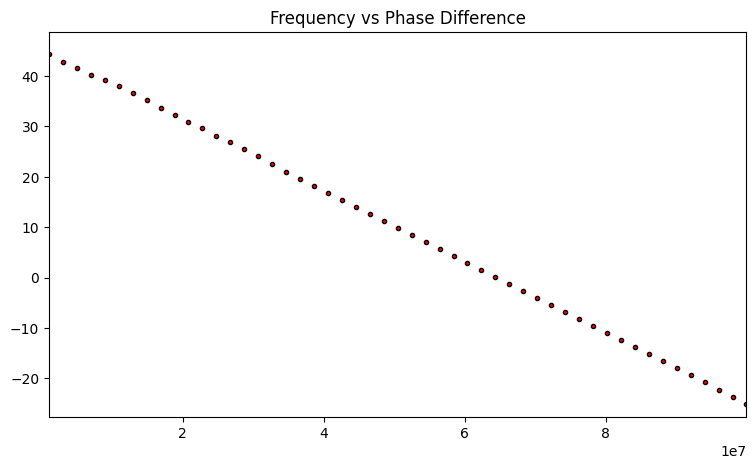

In [46]:
fig, ax = plt.subplots(figsize=(9, 5))

Freq=res1[0]
P_Diff=res1[2]

ax.plot(
    Freq,P_Diff,
    marker='o',         # square markers
    markersize=3,
    markerfacecolor='red',
    markeredgecolor='black',
    linestyle='None'    # disables line
)
    
ax.set_xlim(np.min(Freq),np.max(Freq))
ax.set_ylim(np.min(P_Diff)+0.1*np.min(P_Diff),np.max(P_Diff)+0.1*np.max(P_Diff))
plt.title(f"Frequency vs Phase Difference")
plt.show()

In [ ]:
client.reset_unwrap()

res2=f_sweep(n,freqs)

f1_avg=999997.267697239 Hz; f2_avg=999997.2677732671 Hz; ph_diff_avg=-0.744049072265625 ± 0.00015332854343848098

f1_avg=2979991.837724683 Hz; f2_avg=2979991.837596785 Hz; ph_diff_avg=-2.1330041885375977 ± 0.0001888214186204574

f1_avg=4959986.473319588 Hz; f2_avg=4959986.473442158 Hz; ph_diff_avg=-3.5053499937057495 ± 0.00016699115387579423

f1_avg=6939981.030508591 Hz; f2_avg=6939981.030341613 Hz; ph_diff_avg=-4.875280737876892 ± 0.00020292537653805783

f1_avg=8919975.572317539 Hz; f2_avg=8919975.57244153 Hz; ph_diff_avg=-6.2455140352249146 ± 0.00013945010772404743

f1_avg=10899970.189241515 Hz; f2_avg=10899970.189326426 Hz; ph_diff_avg=-7.615176558494568 ± 0.00021560422932381484

f1_avg=12879964.769455299 Hz; f2_avg=12879964.769558683 Hz; ph_diff_avg=-9.03736960887909 ± 0.0006677043519674434

f1_avg=14859959.401636403 Hz; f2_avg=14859959.401445266 Hz; ph_diff_avg=-10.452305674552917 ± 0.001062246882172575

f1_avg=16839953.981427412 Hz; f2_avg=16839953.981288146 Hz; ph_diff_avg=-11.7

In [84]:
i=0
while i<len(freqs):
    print(f'Calibration={-res2[2][i]+res1[2][i]}\n')
    i+=1

Calibration=0.006036043167114258

Calibration=0.008301973342895508

Calibration=0.010773897171020508

Calibration=0.014541864395141602

Calibration=0.01898038387298584

Calibration=0.012411117553710938

Calibration=0.059516072273254395

Calibration=0.10694503784179688

Calibration=0.08343172073364258

Calibration=0.07678520679473877

Calibration=0.013525843620300293

Calibration=0.08030319213867188

Calibration=0.031822800636291504

Calibration=-0.008000493049621582

Calibration=0.05089223384857178

Calibration=0.07781088352203369

Calibration=0.08008754253387451

Calibration=0.08325576782226562

Calibration=0.08553779125213623

Calibration=0.08639824390411377

Calibration=0.023680686950683594

Calibration=-0.0005375146865844727

Calibration=0.003128528594970703

Calibration=0.0012638568878173828

Calibration=0.01014089584350586

Calibration=0.022111058235168457

Calibration=0.0024139881134033203

Calibration=0.015735983848571777

Calibration=0.011753439903259277

Calibration=0.0174096

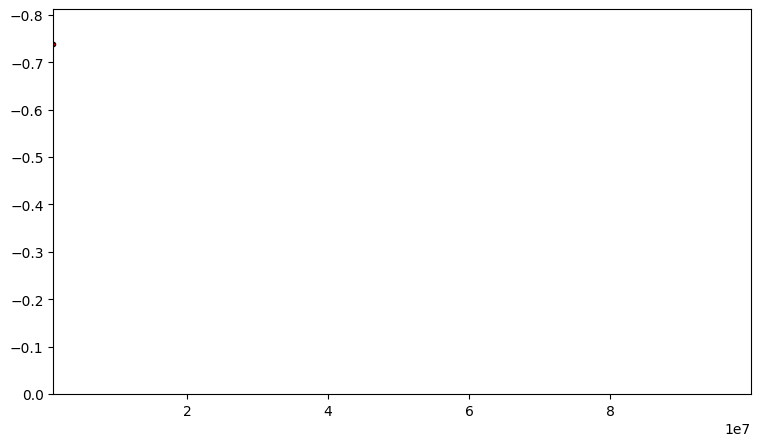

In [85]:
f_Ch1=res1[0]

phase_diff=res1[2]


fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    f_Ch1,phase_diff,
    marker='o',         # square markers
    markersize=3,
    markerfacecolor='red',
    markeredgecolor='black',
    linestyle='None'    # disables line
)
    
ax.set_xlim(np.min(f_Ch1),np.max(f_Ch1))
ax.set_ylim(0,np.max(phase_diff)+0.1*np.max(phase_diff))
#plt.title(f"Power Stability\n Mean={mean:.2f} Std={std:.2f}")
plt.show()

In [25]:
laser.laser_OFF()

'1'

In [26]:
client.close()

In [27]:
gen.close()